# 01. Exploratory Data Analysis (EDA) — Credit Card Fraud Detection

**Project:** Fraud Detection & AI Governance Portfolio by Olivia 👀  
**Data:** [Kaggle Credit Card Fraud Detection](https://www.kaggle.com/mlg-ulb/creditcardfraud)  
**Goal:** Understand the structure and patterns of fraudulent transactions, and build the evidence base for the later modeling and governance stages.

---

### 👀 Dataset at a glance
- ~284K European card transactions (2 days)
- `V1`–`V28`: 28 anonymized features created by applying **PCA** to the original variables
- `Amount`: transaction amount
- `Time`: seconds elapsed since the first transaction
- `Class`: **1 = fraud, 0 = normal**
- **Highly imbalanced:** fraud is only ~0.17% of all transactions

> Every code cell is commented line by line so that someone new to Python can follow along.

## 0. Setup (import libraries)

**What:** Load the tools (libraries) we will use for analysis into memory.  
**Why:** Out of the box, Python has no table or plotting features. We bring in the tools we need with `import` before we can use them.

- `pandas`: works with tables (DataFrames), like a spreadsheet
- `numpy`: numerical computing
- `matplotlib` / `seaborn`: plotting

In [1]:
# pandas: the core tool for tabular data. By convention we give it the short alias pd.
import pandas as pd

# numpy: numerical computing tool. By convention we alias it as np.
import numpy as np

# matplotlib's pyplot: the basic plotting tool. We alias it as plt.
import matplotlib.pyplot as plt

# seaborn: builds on matplotlib to make prettier, statistical plots more easily. Aliased as sns.
import seaborn as sns

# Set a clean 'whitegrid' theme for the overall plot style (background, gridlines, etc.).
sns.set_theme(style="whitegrid")

# Force plain decimal notation so numbers don't show up in scientific form like 1.2e+05.
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Print a confirmation that setup is done.
print("Libraries imported ✅")

Libraries imported ✅


## 1. Load the data + basic info

**What:** Read the CSV into a table (DataFrame) and check its size, data types, and missing values.  
**Why:** The first step of any analysis is understanding what the data looks like. Knowing the number of rows/columns, each column's type, and whether there are empty (missing) values lets us trust everything that follows.

In [2]:
# Path to the data file. This notebook lives in notebooks/, so we go up one level (..) to reach data/.
DATA_PATH = "../data/creditcard.csv"

# read_csv: read the CSV file into a DataFrame (table). Store the result in a variable called df.
df = pd.read_csv(DATA_PATH)

# head(): show the top 5 rows of the table, to eyeball that the data loaded correctly.
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.00,-1.36,-0.07,2.54,1.38,-0.34,0.46,0.24,0.10,0.36,...,-0.02,0.28,-0.11,0.07,0.13,-0.19,0.13,-0.02,149.62,0
1,0.00,1.19,0.27,0.17,0.45,0.06,-0.08,-0.08,0.09,-0.26,...,-0.23,-0.64,0.10,-0.34,0.17,0.13,-0.01,0.01,2.69,0
2,1.00,-1.36,-1.34,1.77,0.38,-0.50,1.80,0.79,0.25,-1.51,...,0.25,0.77,0.91,-0.69,-0.33,-0.14,-0.06,-0.06,378.66,0
3,1.00,-0.97,-0.19,1.79,-0.86,-0.01,1.25,0.24,0.38,-1.39,...,-0.11,0.01,-0.19,-1.18,0.65,-0.22,0.06,0.06,123.50,0
4,2.00,-1.16,0.88,1.55,0.40,-0.41,0.10,0.59,-0.27,0.82,...,-0.01,0.80,-0.14,0.14,-0.21,0.50,0.22,0.22,69.99,0


In [3]:
# shape: gives (number of rows, number of columns). e.g. (284807, 31)
print("Rows, columns:", df.shape)

# Print rows and columns separately for readability. {} inside an f-string is replaced by the value; :, adds thousands commas.
print(f"Transactions (rows): {df.shape[0]:,}")
print(f"Features (columns): {df.shape[1]}")

Rows, columns: (284807, 31)
Transactions (rows): 284,807
Features (columns): 31


In [4]:
# info(): summarizes each column's name, data type (dtype), and count of non-null values.
# A quick way to confirm whether any column has missing values.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [5]:
# isnull(): turns each cell into True if it is empty, otherwise False.
# .sum(): adds up the True (=1) values per column -> how many missing values each column has.
# Calling .sum() once more gives the grand total of missing values.
missing_total = df.isnull().sum().sum()

# Print the total number of missing values. 0 means there are no empty cells at all.
print(f"Total missing values: {missing_total}")

# describe(): shows summary statistics (mean, std, min/max, quartiles) for the numeric columns.
df.describe()

Total missing values: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,"284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00",...,"284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00"
mean,"94,813.86",0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,...,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,88.35,0.00
std,"47,488.15",1.96,1.65,1.52,1.42,1.38,1.33,1.24,1.19,1.10,...,0.73,0.73,0.62,0.61,0.52,0.48,0.40,0.33,250.12,0.04
min,0.00,-56.41,-72.72,-48.33,-5.68,-113.74,-26.16,-43.56,-73.22,-13.43,...,-34.83,-10.93,-44.81,-2.84,-10.30,-2.60,-22.57,-15.43,0.00,0.00
25%,"54,201.50",-0.92,-0.60,-0.89,-0.85,-0.69,-0.77,-0.55,-0.21,-0.64,...,-0.23,-0.54,-0.16,-0.35,-0.32,-0.33,-0.07,-0.05,5.60,0.00
50%,"84,692.00",0.02,0.07,0.18,-0.02,-0.05,-0.27,0.04,0.02,-0.05,...,-0.03,0.01,-0.01,0.04,0.02,-0.05,0.00,0.01,22.00,0.00
75%,"139,320.50",1.32,0.80,1.03,0.74,0.61,0.40,0.57,0.33,0.60,...,0.19,0.53,0.15,0.44,0.35,0.24,0.09,0.08,77.16,0.00
max,"172,792.00",2.45,22.06,9.38,16.88,34.80,73.30,120.59,20.01,15.59,...,27.20,10.50,22.53,4.58,7.52,3.52,31.61,33.85,"25,691.16",1.00


### Interpretation
- The data is **284,807 rows × 31 columns** (`Time`, `V1`–`V28`, `Amount`, `Class`).
- **0 missing values** → no need to fill or drop empty cells. The analysis stays clean.
- `Amount` has a max far above its mean → the amount distribution is likely strongly **right-skewed** (confirmed below).

## 2. Class imbalance

**What:** Count the number and proportion of normal (0) vs fraud (1) transactions and plot them as bars.  
**Why:** The defining trait of fraud detection is **extreme imbalance**. If fraud is only 0.17%, then just predicting "always normal" already yields 99.8% accuracy. That is why accuracy is meaningless here and we must use metrics like Precision/Recall later — we establish that evidence now.

In [6]:
# value_counts(): counts how many times 0 and 1 each appear in the Class column.
class_counts = df["Class"].value_counts()

# normalize=True: counts proportions instead of raw counts. *100 converts to percentages.
class_percent = df["Class"].value_counts(normalize=True) * 100

# Print the counts and then the percentages.
print("Counts:")
print(class_counts)
print("\nPercentages (%):")
print(class_percent.round(3))  # round(3): round to 3 decimal places

Counts:
Class
0    284315
1       492
Name: count, dtype: int64

Percentages (%):
Class
0   99.83
1    0.17
Name: proportion, dtype: float64


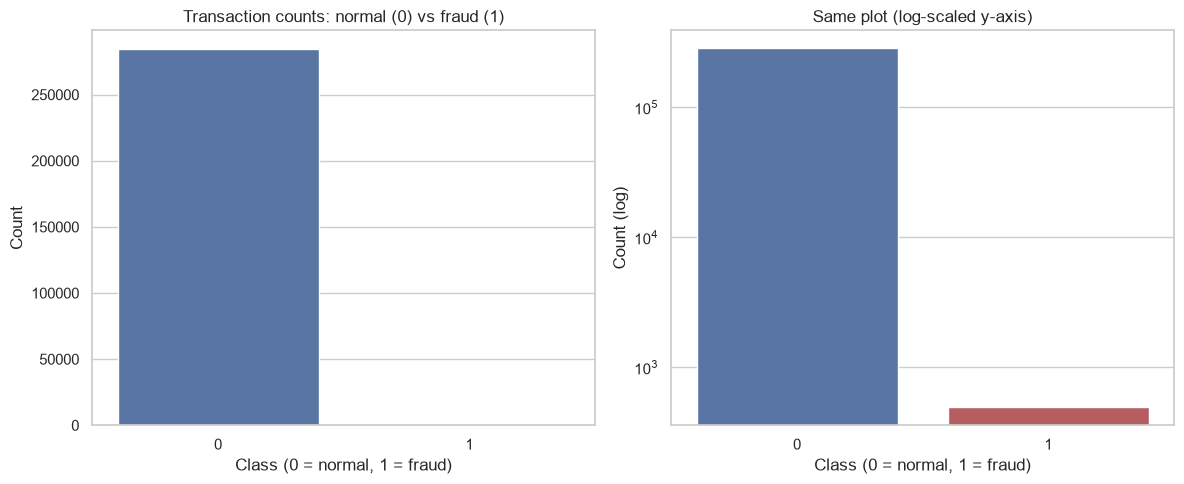

In [7]:
# Create a figure with two side-by-side panels (axes). 1 row, 2 columns, size 12x5.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -- Left plot: raw counts --
# countplot: draws a bar for the count of each Class value. ax=axes[0] means "draw in the left panel".
sns.countplot(data=df, x="Class", ax=axes[0], palette=["#4C72B0", "#C44E52"], hue="Class", legend=False)
axes[0].set_title("Transaction counts: normal (0) vs fraud (1)")  # plot title
axes[0].set_xlabel("Class (0 = normal, 1 = fraud)")               # x-axis label
axes[0].set_ylabel("Count")                                       # y-axis label

# -- Right plot: log scale --
# Fraud is so rare it is invisible on a normal bar. Switching the y-axis to log scale makes small values visible.
sns.countplot(data=df, x="Class", ax=axes[1], palette=["#4C72B0", "#C44E52"], hue="Class", legend=False)
axes[1].set_yscale("log")  # change the y-axis to a log scale
axes[1].set_title("Same plot (log-scaled y-axis)")
axes[1].set_xlabel("Class (0 = normal, 1 = fraud)")
axes[1].set_ylabel("Count (log)")

# Auto-adjust spacing so the plots don't overlap, then display.
plt.tight_layout()
plt.show()

### Interpretation
- Normal transactions: **284,315 (99.83%)**; fraud: **492 (0.17%)** — an extreme imbalance of roughly **578 : 1**.
- In the left plot the fraud bar is essentially invisible → only the log-scaled right plot confirms it exists.
- **Modeling implication:** accuracy is useless. Use **Recall (fraction of fraud caught)**, **Precision**, and **PR-AUC** as the key metrics. Also consider `class_weight` tuning or resampling (e.g. SMOTE) during training.

## 3. Transaction amount (Amount) — fraud vs normal

**What:** Compare the amount distribution of normal vs fraudulent transactions.  
**Why:** Test the intuition "do fraudulent transactions sit in a different amount range?" against the data. Knowing whether amount is a useful signal tells us early which features the model may rely on.

In [8]:
# Compare Amount statistics separately for normal (Class==0) and fraud (Class==1) transactions.
# groupby("Class"): split into groups by Class value, then describe() the ["Amount"] stats of each group.
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,"284,315.00",88.29,250.11,0.00,5.65,22.00,77.05,"25,691.16"
1,492.00,122.21,256.68,0.00,1.00,9.25,105.89,"2,125.87"


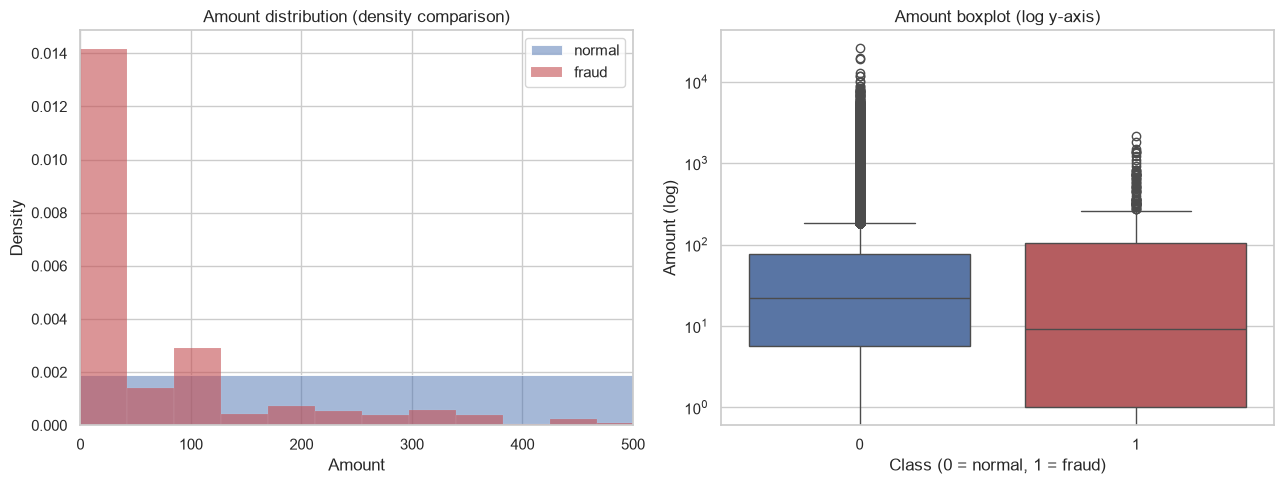

In [9]:
# Figure with two side-by-side panels.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- Left: amount distribution, normal vs fraud (histogram) --
# Select only the amounts of normal transactions. df[condition] keeps rows where the condition is True.
normal_amount = df[df["Class"] == 0]["Amount"]
# Select only the amounts of fraud transactions.
fraud_amount = df[df["Class"] == 1]["Amount"]

# Histogram of normal amounts. bins=50: split into 50 bars. alpha: transparency. stat="density": compare shapes, not raw counts.
sns.histplot(normal_amount, bins=50, color="#4C72B0", label="normal", ax=axes[0], stat="density", alpha=0.5)
sns.histplot(fraud_amount, bins=50, color="#C44E52", label="fraud", ax=axes[0], stat="density", alpha=0.6)
axes[0].set_title("Amount distribution (density comparison)")
axes[0].set_xlabel("Amount")
axes[0].set_xlim(0, 500)   # large amounts are rare, so zoom into the 0-500 range.
axes[0].legend()           # show the legend (which color is normal/fraud)

# -- Right: boxplot to compare medians and outliers --
# boxplot: shows each group's median, quartiles, and outliers as a box.
sns.boxplot(data=df, x="Class", y="Amount", ax=axes[1], palette=["#4C72B0", "#C44E52"], hue="Class", legend=False)
axes[1].set_yscale("log")  # amounts vary a lot, so a log scale is needed for the boxes to be visible.
axes[1].set_title("Amount boxplot (log y-axis)")
axes[1].set_xlabel("Class (0 = normal, 1 = fraud)")
axes[1].set_ylabel("Amount (log)")

plt.tight_layout()
plt.show()

### Interpretation
- Both normal and fraud transactions cluster at **small amounts** (a long right tail — right-skewed).
- Fraud has a somewhat higher **mean amount (~122)** than normal (~88), but the distributions overlap heavily, so **amount alone cannot separate fraud well.**
- **Implication:** `Amount` is only a supporting signal with weak standalone power. Its large spread also means we need **scaling (StandardScaler / log transform)** before model training.

## 4. Time pattern — fraud by hour

**What:** Convert `Time` (seconds since the first transaction) into hours and look at the flow of normal/fraud transactions by hour.
**Why:** Check whether fraud concentrates in certain hours (e.g. late night). If there is a time pattern, "transaction time" could be a useful feature.

In [10]:
# Time is 'seconds since the first transaction'. Dividing by 3600 converts it to hours.
# The data spans 2 days (0-48 hours). Taking the remainder mod 24 gives the hour of day (0-23h).
df["Hour"] = (df["Time"] / 3600) % 24

# Check that the new Hour column was added correctly by viewing the first rows.
df[["Time", "Hour", "Class"]].head()

,Time,Hour,Class
0,0.00,0.00,0
1,0.00,0.00,0
2,1.00,0.00,0
3,1.00,0.00,0
4,2.00,0.00,0


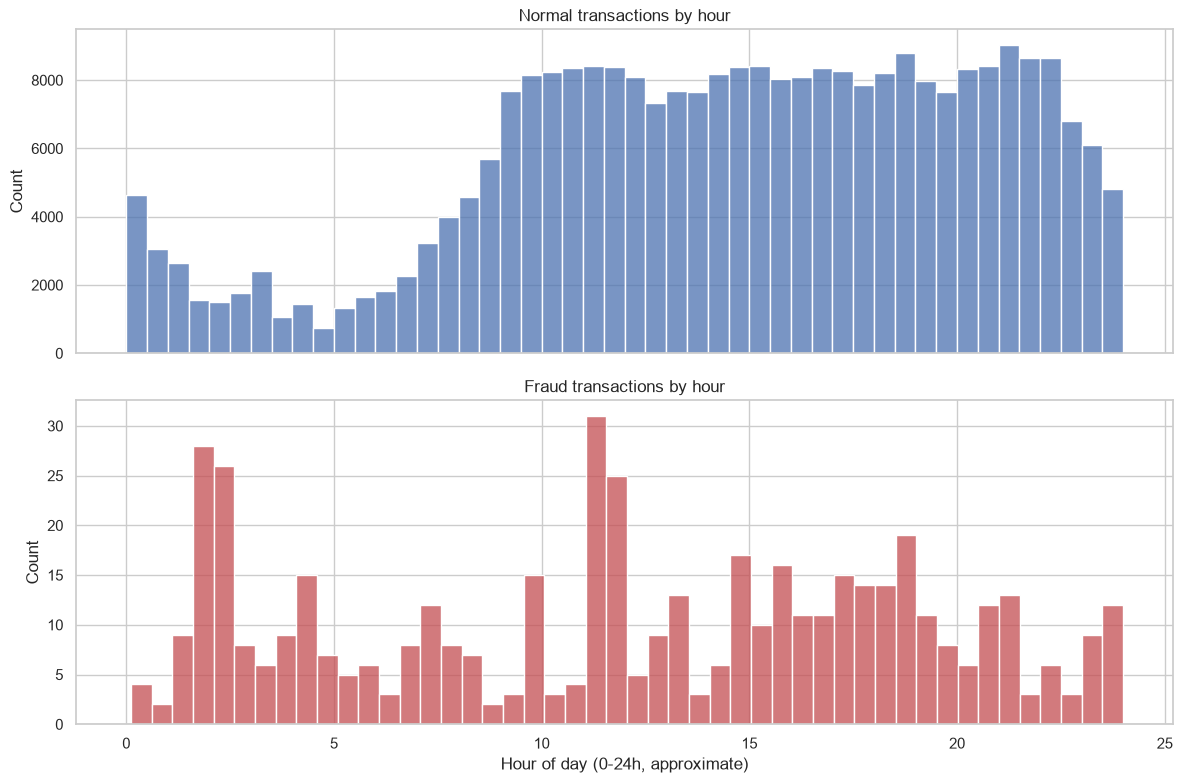

In [11]:
# Figure with two stacked panels (top/bottom). sharex=True: both share the same x-axis (time).
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# -- Top: hourly distribution of normal transactions --
sns.histplot(df[df["Class"] == 0]["Hour"], bins=48, color="#4C72B0", ax=axes[0])
axes[0].set_title("Normal transactions by hour")
axes[0].set_ylabel("Count")

# -- Bottom: hourly distribution of fraud transactions --
sns.histplot(df[df["Class"] == 1]["Hour"], bins=48, color="#C44E52", ax=axes[1])
axes[1].set_title("Fraud transactions by hour")
axes[1].set_xlabel("Hour of day (0-24h, approximate)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

### Interpretation
- Normal transactions follow a natural daily rhythm: **busy during the day, quieter overnight.**
- Fraud has a weaker periodic pattern, but it **keeps occurring in the overnight hours when normal traffic is low** → possibly targeting times when monitoring is lax.
- **Caveat:** the data is only 2 days long, so the sample is too small to generalize the time pattern. Treat `Hour` as a weak supporting feature only.

## 5. Correlation heatmap (V1–V28)

**What:** Visualize the correlations among the PCA features `V1`–`V28` and `Class` as colors.
**Why:** Finding which V features move strongly with the fraud label (`Class`) tells us in advance where the model will get its signal. Since the PCA features are independent, the V's should correlate weakly with each other — that is expected.

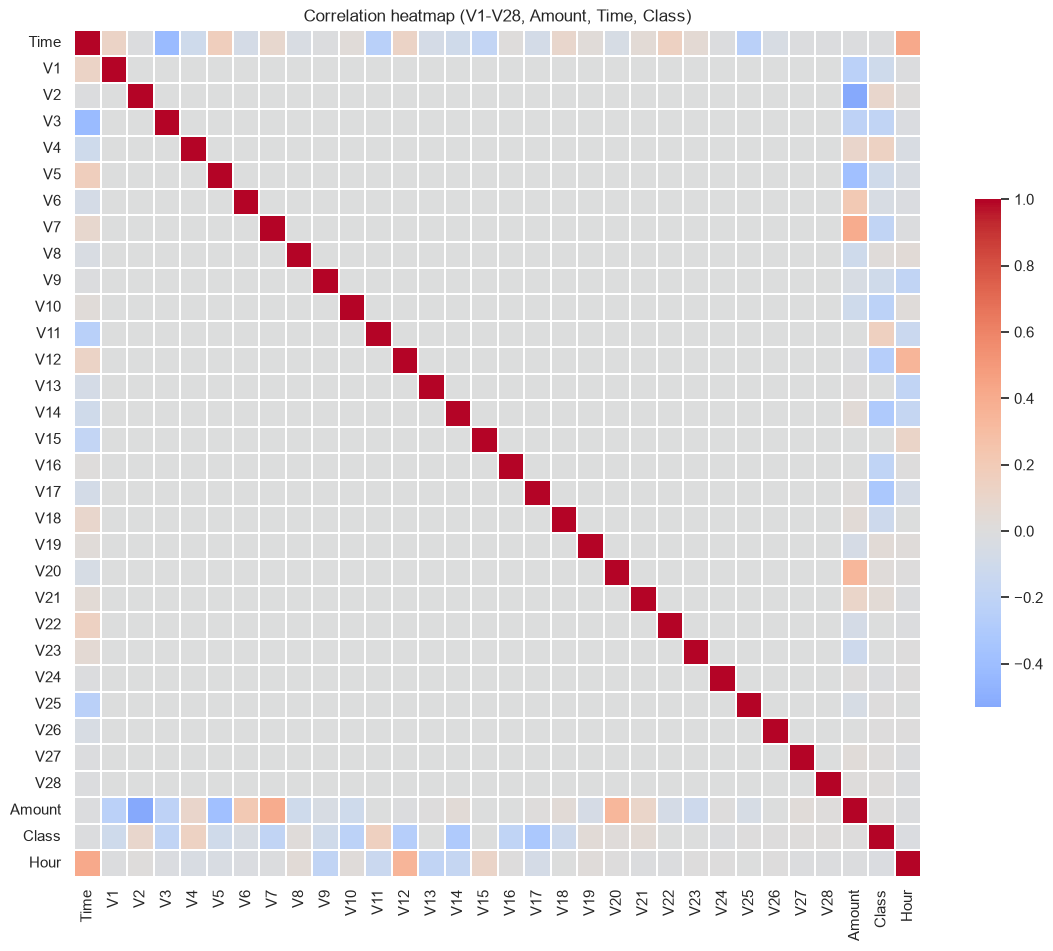

In [12]:
# corr(): computes the correlation coefficient (-1 to +1) for every pair of numeric columns.
# +1 = move together / -1 = move oppositely / 0 = unrelated.
corr = df.corr(numeric_only=True)

# Use a large figure (30 features need plenty of room to be readable).
plt.figure(figsize=(14, 11))

# heatmap: draw the correlation table as colors. cmap: color palette. center=0: 0 maps to the middle color.
# With this many features we skip the numeric annotations and read the pattern by color only.
sns.heatmap(corr, cmap="coolwarm", center=0, square=True,
            linewidths=0.3, cbar_kws={"shrink": 0.6})
plt.title("Correlation heatmap (V1-V28, Amount, Time, Class)")
plt.show()

In [13]:
# Pull out just the correlations with Class and sort by absolute value to find the key features.
# corr["Class"]: correlation of the Class column with every other variable.
# .drop("Class"): exclude itself (Class vs Class = 1.0).
class_corr = corr["Class"].drop("Class")

# abs(): absolute value (ignore sign, keep strength). sort_values(ascending=False): largest first.
class_corr_sorted = class_corr.abs().sort_values(ascending=False)

# Print the top 10 variables. These are the most associated with fraud.
print("Top 10 variables most correlated with Class:")
print(class_corr_sorted.head(10).round(3))

Top 10 variables most correlated with Class:
V17   0.33
V14   0.30
V12   0.26
V10   0.22
V16   0.20
V3    0.19
V7    0.19
V11   0.15
V4    0.13
V18   0.11
Name: Class, dtype: float64


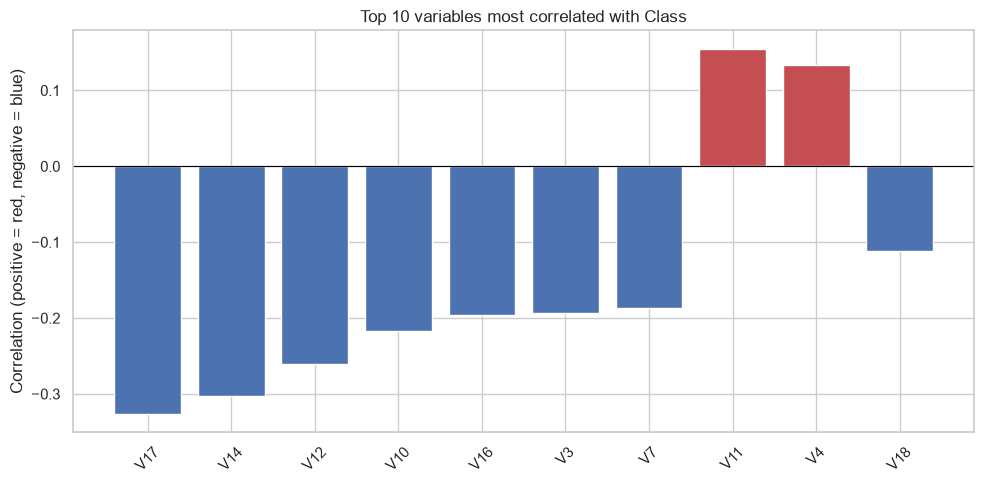

In [14]:
# Plot the top variables as bars to visualize which carry the strongest fraud signal.
top10 = class_corr_sorted.head(10).index          # names of the top 10 variables
top10_values = class_corr[top10]                  # their actual (signed) correlation values

plt.figure(figsize=(10, 5))
# Color bars by sign: positive (+) red, negative (-) blue.
colors = ["#C44E52" if v > 0 else "#4C72B0" for v in top10_values]
plt.bar(top10, top10_values, color=colors)
plt.axhline(0, color="black", linewidth=0.8)      # zero reference line
plt.title("Top 10 variables most correlated with Class")
plt.ylabel("Correlation (positive = red, negative = blue)")
plt.xticks(rotation=45)                            # tilt x labels 45 deg to avoid overlap
plt.tight_layout()
plt.show()

### Interpretation
- The `V1`–`V28` features correlate near 0 with each other → expected, since PCA produces orthogonal/independent components.
- The variables most correlated with `Class` are mainly **V17, V14, V12, V10, V16, V11, V9** (the sign/direction varies by variable).
- **Implication:** these are likely the model's key inputs. Later we can check whether the model's feature importances agree with this EDA — a cross-check that supports model trustworthiness (a governance concern).

## 6. Key Findings

| # | Finding | Modeling / governance implication |
|---|---------|-----------------------------------|
| 1 | **0 missing values**, 284,807 rows × 31 cols | No missing-value handling needed; clean data |
| 2 | **Extreme imbalance** (fraud 0.17%, ~578:1) | No accuracy → use **Recall / Precision / PR-AUC**, consider class_weight / resampling |
| 3 | **Amount** slightly higher for fraud but overlapping | Weak standalone signal; needs **scaling** before training |
| 4 | **Time** fraud persists overnight | Weak supporting feature; only 2 days, so generalize cautiously |
| 5 | **V17, V14, V12, V10** etc. strongly correlate with Class | Key feature candidates; cross-check during model interpretation |

---

### Next Steps
1. **02_Preprocessing:** scale `Amount`/`Time`, train/test split (stratify to preserve imbalance)
2. **03_Modeling:** Logistic Regression (baseline) → Random Forest / XGBoost, compare imbalance handling
3. **04_Evaluation:** PR-Curve, Confusion Matrix, threshold tuning
4. **05_AI_Governance:** model card, feature importance vs EDA cross-check, fairness & explainability docs

> **AI Risk Analyst angle:** the imbalance and the key variables found in EDA become the evidence for the governance document that explains **why the model decided the way it did.**